In [1]:
import os, zipfile, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

DATA_DIR = Path('../data/raw')
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('Setup OK')

Setup OK


In [2]:
URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
ZIP_PATH = DATA_DIR / 'ml-latest-small.zip'

if not ZIP_PATH.exists():
    r = requests.get(URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(ZIP_PATH, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk); bar.update(len(chunk))

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

ML_DIR  = DATA_DIR / 'ml-latest-small'
ratings = pd.read_csv(ML_DIR / 'ratings.csv')
movies  = pd.read_csv(ML_DIR / 'movies.csv')
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')

print(f'Ratings : {len(ratings):,}')
print(f'Films   : {movies.movieId.nunique():,}')
print(f'Users   : {ratings.userId.nunique():,}')
ratings.head()

100%|█████████████████████████████████████████████| 978k/978k [00:01<00:00, 841kB/s]

Ratings : 100,836
Films   : 9,742
Users   : 610


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


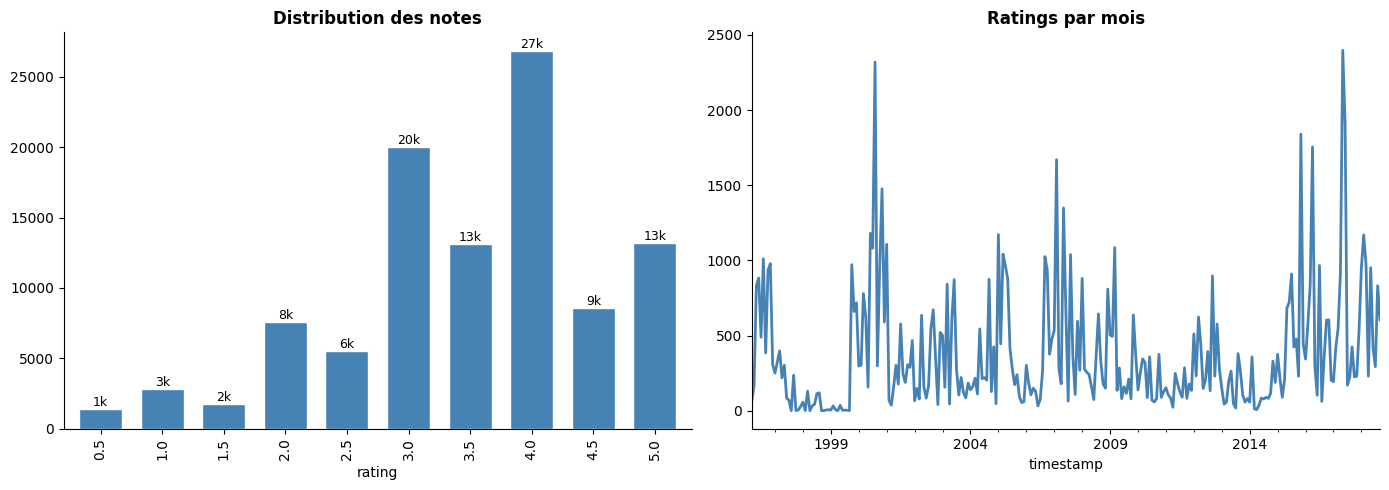

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des notes
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white', width=0.7
)
axes[0].set_title('Distribution des notes', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()/1000:.0f}k',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=9)

# Évolution temporelle
ratings.set_index('timestamp').resample('ME')['rating'].count().plot(
    ax=axes[1], color='steelblue', linewidth=2
)
axes[1].set_title('Ratings par mois', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/01_rating_distribution.png', dpi=150)
plt.show()

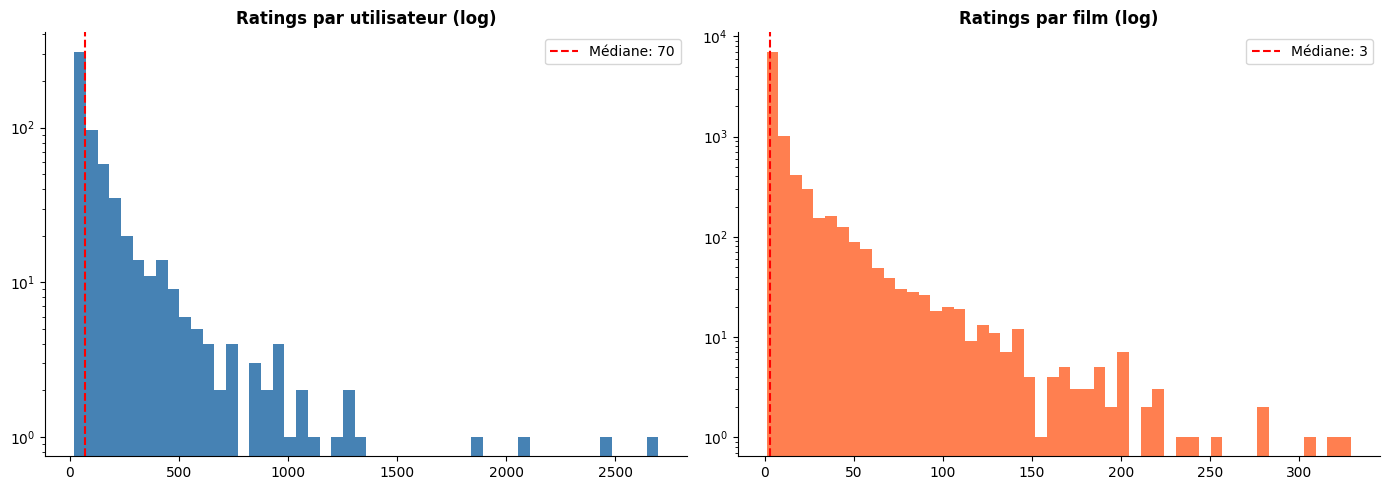

In [4]:
ratings_per_user  = ratings.groupby('userId')['rating'].count()
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings_per_user,  bins=50, color='steelblue', log=True)
axes[0].set_title('Ratings par utilisateur (log)', fontweight='bold')
axes[0].axvline(ratings_per_user.median(), color='red', linestyle='--',
    label=f'Médiane: {ratings_per_user.median():.0f}')
axes[0].legend()

axes[1].hist(ratings_per_movie, bins=50, color='coral', log=True)
axes[1].set_title('Ratings par film (log)', fontweight='bold')
axes[1].axvline(ratings_per_movie.median(), color='red', linestyle='--',
    label=f'Médiane: {ratings_per_movie.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/02_activity_distribution.png', dpi=150)
plt.show()

Matrice  : 610 users x 9,724 films
Sparsité : 98.3000%


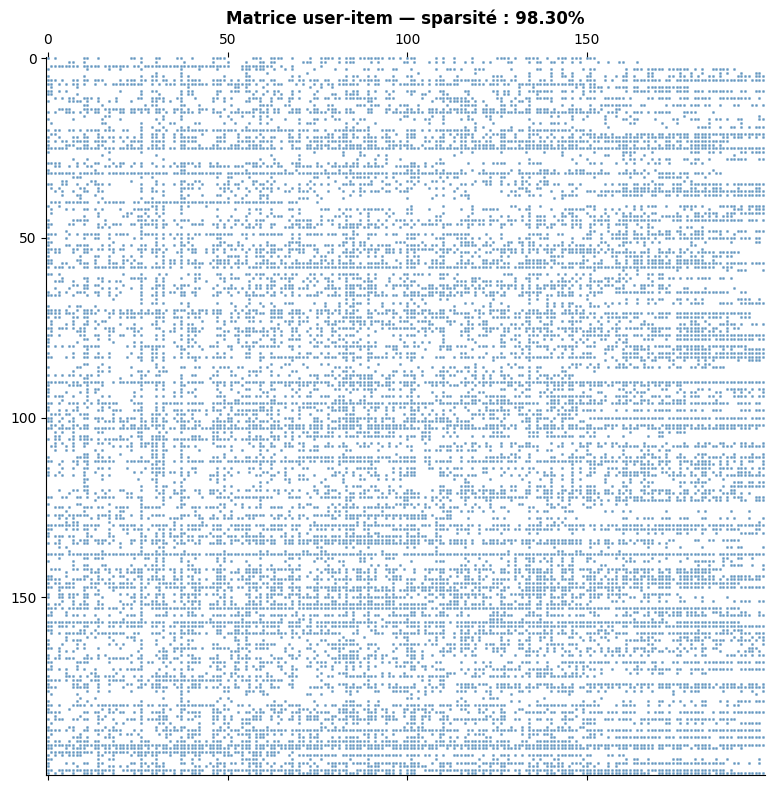

In [5]:
n_users   = ratings['userId'].nunique()
n_movies  = ratings['movieId'].nunique()
sparsity  = 1 - len(ratings) / (n_users * n_movies)

print(f'Matrice  : {n_users:,} users x {n_movies:,} films')
print(f'Sparsité : {sparsity:.4%}')  # ~98% attendu

# Visualisation sur sous-échantillon 200x200
top_users  = ratings['userId'].value_counts().head(200).index
top_movies = ratings['movieId'].value_counts().head(200).index
subset = ratings[
    ratings['userId'].isin(top_users) &
    ratings['movieId'].isin(top_movies)
]
pivot = subset.pivot_table(index='userId', columns='movieId', values='rating')

fig, ax = plt.subplots(figsize=(10, 8))
ax.spy(pivot.notna(), markersize=1, color='steelblue', alpha=0.6)
ax.set_title(f'Matrice user-item — sparsité : {sparsity:.2%}', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_sparsity_matrix.png', dpi=150)
plt.show()

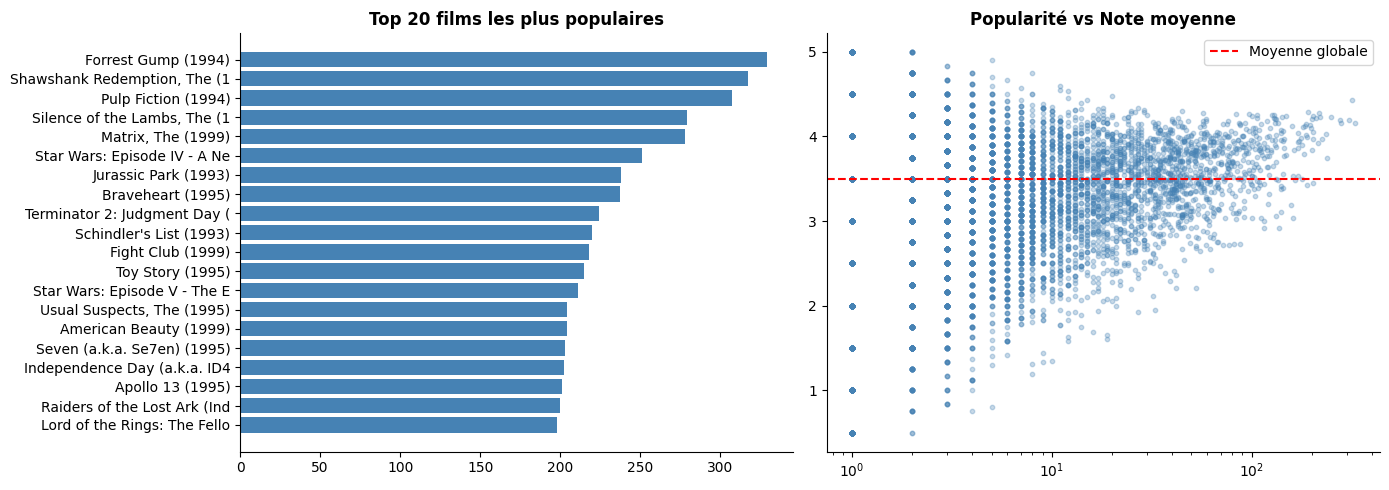

In [6]:
movie_stats = ratings.groupby('movieId').agg(
    n_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index().merge(movies[['movieId', 'title', 'genres']], on='movieId')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 films les plus notés
top20 = movie_stats.nlargest(20, 'n_ratings')
axes[0].barh(top20['title'].str[:28][::-1], top20['n_ratings'][::-1], color='steelblue')
axes[0].set_title('Top 20 films les plus populaires', fontweight='bold')

# Popularité vs note moyenne
axes[1].scatter(movie_stats['n_ratings'], movie_stats['avg_rating'],
    alpha=0.3, s=10, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_title('Popularité vs Note moyenne', fontweight='bold')
axes[1].axhline(ratings['rating'].mean(), color='red', linestyle='--', label='Moyenne globale')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/04_popularity_bias.png', dpi=150)
plt.show()

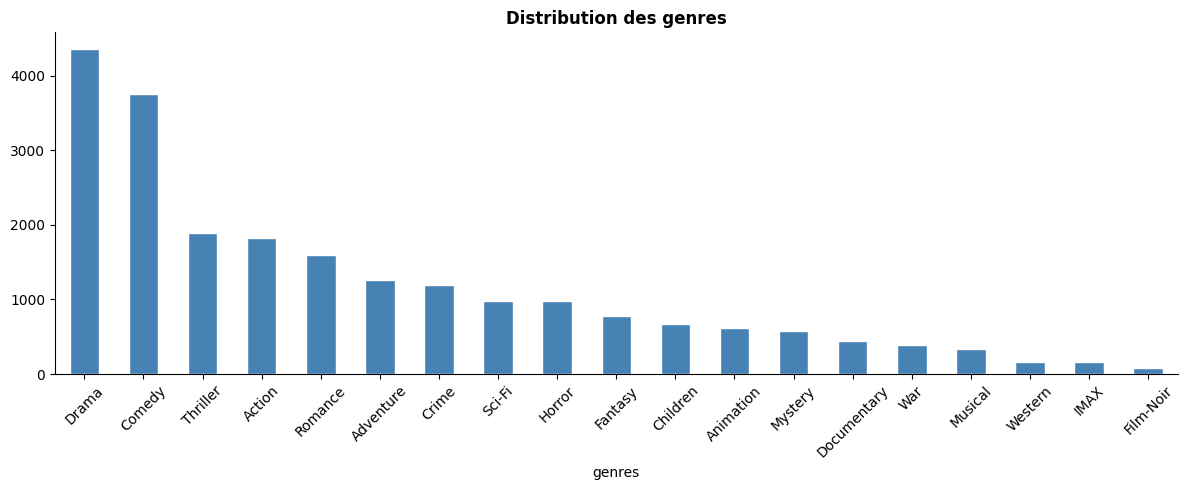

=== RÉCAPITULATIF EDA ===
Ratings     : 100,836
Utilisateurs: 610
Films       : 9,724
Sparsité    : 98.30%
Note moy.   : 3.50/5
EDA terminée !


In [7]:
# Distribution des genres
genre_counts = movies['genres'].str.split('|').explode().value_counts()
genre_counts = genre_counts[genre_counts.index != '(no genres listed)']

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution des genres', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/05_genres.png', dpi=150)
plt.show()

# Récapitulatif final
print('=== RÉCAPITULATIF EDA ===')
print(f'Ratings     : {len(ratings):,}')
print(f'Utilisateurs: {n_users:,}')
print(f'Films       : {n_movies:,}')
print(f'Sparsité    : {sparsity:.2%}')
print(f'Note moy.   : {ratings["rating"].mean():.2f}/5')
print('EDA terminée !')